In [1]:
import scanpy as sc
import scirpy as ir
import pandas as pd
import shutil
from tqdm import tqdm
import anndata as an
import numpy as np

/home/jupyter/mambaforge/envs/mvTCR/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Preprocessing

In [2]:
import os
!gsutil -m cp gs://vm_backups_arnav/ge_korea/raw_data/count_matricies/raw_combined.h5ad {'/home/jupyter/data/ge_korea/raw_data/count_matricies/raw_combined.h5ad'}
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/raw_data/count_matricies/raw_combined.h5ad')
os.remove('/home/jupyter/data/ge_korea/raw_data/count_matricies/raw_combined.h5ad')

Copying gs://vm_backups_arnav/ge_korea/raw_data/count_matricies/raw_combined.h5ad...
- [1/1 files][  5.2 GiB/  5.2 GiB] 100% Done  76.8 MiB/s ETA 00:00:00           
Operation completed over 1 objects/5.2 GiB.                                      


/home/jupyter/mambaforge/envs/mvTCR/lib/python3.8/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [3]:
adata

AnnData object with n_obs × n_vars = 654770 × 36601
    obs: 'sample', 'patient', 'timepoint', 'normal', 'batch'
    var: 'gene_ids', 'feature_types'

In [4]:
adata.obs['stripped_index'] = [item.split('-')[0] for item in adata.obs.index.tolist()]
adata.obs['sample_index'] = adata.obs[['sample', 'stripped_index']].agg('_'.join, axis=1)

In [5]:
del adata.obs['stripped_index']
adata.obs = adata.obs.set_index('sample_index')

In [6]:
sample_list = adata.obs['sample'].unique().tolist()

In [7]:
#for sample in tqdm(sample_list):
#    if 'AN' in sample or 'DN' in sample:
#        continue
#    shutil.rmtree(f'/home/jupyter/data/ge_korea/results/tcr_analysis/cellranger_outputs/{sample}/')

In [8]:
#for sample in tqdm(sample_list):
#    if 'AN' in sample or 'DN' in sample:
#        continue
#    dest = f'/home/jupyter/data/ge_korea/results/tcr_analysis/cellranger_outputs/{sample}/'
#    !mkdir -p {dest}
#    if sample == 'E22_B':
#        sample = 'E22'
#    input_path = !gsutil ls gs://vm_backups_arnav/ge_korea/raw_data/TCR/cellranger_vdj_outputs/{sample}
#    input_path = input_path[0]
#    input_path += 'all_contig_annotations.json'
#    !gsutil -m cp {input_path} {dest}

In [9]:
tcr_dict = {}
for sample in tqdm(sample_list):
    if 'AN' in sample or 'DN' in sample:
        continue
    tcr_dict[sample] = ir.io.read_10x_vdj(f'/home/jupyter/data/ge_korea/results/tcr_analysis/cellranger_outputs/{sample}/all_contig_annotations.json')

  0%|          | 0/138 [00:00<?, ?it/s]WARNING: Non-standard locus name ignored: None 
/home/jupyter/mambaforge/envs/mvTCR/lib/python3.8/site-packages/scirpy/io/_convert_anndata.py:81: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = AnnData(obs=ir_df, X=np.empty([ir_df.shape[0], 0]))
100%|██████████| 138/138 [00:57<00:00,  2.39it/s]


In [10]:
for sample in tqdm(sample_list):
    if 'AN' in sample or 'DN' in sample:
        continue
    tcr_adata = tcr_dict[sample].copy()
    tcr_adata.obs['sample'] = sample
    tcr_adata.obs['stripped_index'] = [item.split('-')[0] for item in tcr_adata.obs.index.tolist()]
    tcr_adata.obs['sample_index'] = tcr_adata.obs[['sample', 'stripped_index']].agg('_'.join, axis=1)
    del tcr_adata.obs['stripped_index']
    tcr_adata.obs = tcr_adata.obs.set_index('sample_index')
    tcr_dict[sample] = tcr_adata

100%|██████████| 138/138 [00:03<00:00, 38.23it/s]


In [11]:
tcr_adata = an.concat(list(tcr_dict.values()), join='outer', merge='same', uns_merge='same')

In [12]:
tcr_total_by_sample = tcr_adata.obs['sample'].value_counts()

In [13]:
tcr_adata

AnnData object with n_obs × n_vars = 94762 × 0
    obs: 'is_cell', 'high_confidence', 'multi_chain', 'extra_chains', 'IR_VJ_1_c_call', 'IR_VJ_2_c_call', 'IR_VDJ_1_c_call', 'IR_VDJ_2_c_call', 'IR_VJ_1_consensus_count', 'IR_VJ_2_consensus_count', 'IR_VDJ_1_consensus_count', 'IR_VDJ_2_consensus_count', 'IR_VJ_1_d_call', 'IR_VJ_2_d_call', 'IR_VDJ_1_d_call', 'IR_VDJ_2_d_call', 'IR_VJ_1_duplicate_count', 'IR_VJ_2_duplicate_count', 'IR_VDJ_1_duplicate_count', 'IR_VDJ_2_duplicate_count', 'IR_VJ_1_j_call', 'IR_VJ_2_j_call', 'IR_VDJ_1_j_call', 'IR_VDJ_2_j_call', 'IR_VJ_1_junction', 'IR_VJ_2_junction', 'IR_VDJ_1_junction', 'IR_VDJ_2_junction', 'IR_VJ_1_junction_aa', 'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa', 'IR_VJ_1_locus', 'IR_VJ_2_locus', 'IR_VDJ_1_locus', 'IR_VDJ_2_locus', 'IR_VJ_1_productive', 'IR_VJ_2_productive', 'IR_VDJ_1_productive', 'IR_VDJ_2_productive', 'IR_VJ_1_v_call', 'IR_VJ_2_v_call', 'IR_VDJ_1_v_call', 'IR_VDJ_2_v_call', 'has_ir', 'sample'
    uns: 'sc

In [14]:
adata

AnnData object with n_obs × n_vars = 654770 × 36601
    obs: 'sample', 'patient', 'timepoint', 'normal', 'batch'
    var: 'gene_ids', 'feature_types'

In [15]:
ir.pp.merge_with_ir(adata, tcr_adata)

In [16]:
adata

AnnData object with n_obs × n_vars = 654770 × 36601
    obs: 'sample_x', 'patient', 'timepoint', 'normal', 'batch', 'is_cell', 'high_confidence', 'multi_chain', 'extra_chains', 'IR_VJ_1_c_call', 'IR_VJ_2_c_call', 'IR_VDJ_1_c_call', 'IR_VDJ_2_c_call', 'IR_VJ_1_consensus_count', 'IR_VJ_2_consensus_count', 'IR_VDJ_1_consensus_count', 'IR_VDJ_2_consensus_count', 'IR_VJ_1_d_call', 'IR_VJ_2_d_call', 'IR_VDJ_1_d_call', 'IR_VDJ_2_d_call', 'IR_VJ_1_duplicate_count', 'IR_VJ_2_duplicate_count', 'IR_VDJ_1_duplicate_count', 'IR_VDJ_2_duplicate_count', 'IR_VJ_1_j_call', 'IR_VJ_2_j_call', 'IR_VDJ_1_j_call', 'IR_VDJ_2_j_call', 'IR_VJ_1_junction', 'IR_VJ_2_junction', 'IR_VDJ_1_junction', 'IR_VDJ_2_junction', 'IR_VJ_1_junction_aa', 'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa', 'IR_VJ_1_locus', 'IR_VJ_2_locus', 'IR_VDJ_1_locus', 'IR_VDJ_2_locus', 'IR_VJ_1_productive', 'IR_VJ_2_productive', 'IR_VDJ_1_productive', 'IR_VDJ_2_productive', 'IR_VJ_1_v_call', 'IR_VJ_2_v_call', 'IR_VDJ_1

In [17]:
print(len(adata))
adata = adata[~adata.obs['IR_VDJ_1_junction_aa'].isna()]
adata = adata[~adata.obs['IR_VJ_1_junction_aa'].isna()].copy()
print(len(adata))

654770
73652


In [18]:
tcr_aa_by_sample = adata.obs['sample_x'].value_counts()

In [19]:
ir.tl.chain_qc(adata)
ir.pp.ir_dist(adata)
ir.tl.define_clonotypes(adata, key_added='clonotype', receptor_arms='all', dual_ir='primary_only')

100%|██████████| 44384/44384 [01:10<00:00, 625.44it/s]


In [20]:
from tcr_embedding.utils_preprocessing import encode_tcr

len_beta = adata.obs['IR_VDJ_1_junction_aa'].str.len().max()
len_alpha= adata.obs['IR_VJ_1_junction_aa'].str.len().max()
pad = max(len_beta, len_alpha)

encode_tcr(adata, 'IR_VJ_1_junction_aa', 'IR_VDJ_1_junction_aa', pad)

In [21]:
from sklearn.preprocessing import OneHotEncoder

In [22]:
enc = OneHotEncoder(sparse=False)
enc.fit(adata.obs['sample_x'].to_numpy().reshape(-1, 1))
adata.obsm['sample_x'] = enc.transform(adata.obs['sample_x'].to_numpy().reshape(-1, 1))
adata.uns['sample_x_enc'] = enc.categories_

## Merge Annotations

In [23]:
adata_annot = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_final_annot_new.h5ad')

In [24]:
adata_annot.obs['annot_final'].unique().tolist()

['Plasma',
 'B',
 'Epithelial',
 'Capillary Endothelial',
 'Pericyte',
 'iCAF',
 'Venuous Endothelial',
 'SMC',
 'Schwann',
 'Lymphatic Endothelial',
 'C1QC Macrophage',
 'cDC2',
 'Monocyte',
 'CD14 Monocyte',
 'Mast',
 'mregDC',
 'SPP1 Macrophage',
 'cDC1',
 'pDC',
 'Treg',
 'Tactiv Cell',
 'CD8 Tem Cell',
 'Th17',
 'GZMK+ CD8 T progenitor ex Cell',
 'T naive/early memory Cell',
 'Th17/Tc17',
 'NK',
 'gd T Cell',
 'Tc17',
 'CD8 Cytotoxic T Cell',
 'CD8 HSP T cell',
 'Tprolif Cell',
 'NKT',
 'Terminal CD8 Tex Cell']

In [25]:
t_cell_total_by_sample = adata_annot[(adata_annot.obs['annot_final'].isin(['Treg',
 'Tactiv Cell',
 'CD8 Tem Cell',
 'Th17',
 'GZMK+ CD8 T progenitor ex Cell',
 'T naive/early memory Cell',
 'Th17/Tc17',
 'gd T Cell',
 'Tc17',
 'CD8 Cytotoxic T Cell',
 'CD8 HSP T cell',
 'Tprolif Cell',
 'NKT',
 'Terminal CD8 Tex Cell']) & (adata_annot.obs['normal'].isnull()))].obs['sample'].value_counts()

In [26]:
t_cell_total_by_sample

E17_F2    4424
E29_B     3238
E39_F2    3221
E12_F1    2906
E18_F1    2880
          ... 
E45_F2      83
E33_F1      77
E27_F2      68
E29_F2      32
E46_F2      32
Name: sample, Length: 94, dtype: int64

In [27]:
adata_annot.obs['stripped_index'] = [item.split('-')[0] for item in adata_annot.obs.index.tolist()]
adata_annot.obs['sample_index'] = adata_annot.obs[['sample', 'stripped_index']].agg('_'.join, axis=1)

In [28]:
del adata_annot.obs['stripped_index']
adata_annot.obs = adata_annot.obs.set_index('sample_index')

In [29]:
adata_annot.obs['annot_final']

sample_index
E30_F1_AAACCTGTCAAGATCC              Plasma
E30_F1_AAGGTTCAGAGGACGG              Plasma
E30_F1_ACGCAGCCAATCGAAA              Plasma
E30_F1_ACGGGTCCAGCCAGAA              Plasma
E30_F1_ACTTGTTTCGAGAACG              Plasma
                                  ...      
E43_B_DN_TTTGCGCGTTGAGTTC    CD8 HSP T cell
E43_B_DN_TTTGTCAAGTGCGTGA      CD8 Tem Cell
E43_B_DN_TTTGTCACAAGCGAGT                NK
E43_B_DN_TTTGTCACAGCGTTCG      CD8 Tem Cell
E43_B_DN_TTTGTCAGTACCCAAT      CD8 Tem Cell
Name: annot_final, Length: 392977, dtype: category
Categories (34, object): ['B', 'C1QC Macrophage', 'CD8 Cytotoxic T Cell', 'CD8 HSP T cell', ..., 'gd T Cell', 'iCAF', 'mregDC', 'pDC']

In [30]:
adata.obs['annot_final'] = adata_annot.obs['annot_final']

In [31]:
np.sum(adata.obs['annot_final'].value_counts())

68525

In [32]:
tcr_annot_by_sample = adata[~adata.obs['annot_final'].isnull()].obs['sample_x'].value_counts()

In [33]:
non_t = [
    'Plasma','Epithelial','NK','C1QC Macrophage','B','iCAF','Mast','cDC2','CD14 Monocyte','Venuous Endothelial','mregDC',
    'SPP1 Macrophage','SMC','Capillary Endothelial','cDC1','Pericyte','pDC','Monocyte'
]

In [34]:
temp = adata[adata.obs['annot_final'].isin(non_t)]
temp_dict = {}
for i in temp.obs['sample_x'].sort_values().unique():
    temp_dict[i] = temp[temp.obs['sample_x'] == i].obs['annot_final'].value_counts()

In [35]:
temp.obs['annot_final'].value_counts()

Plasma                   545
Epithelial               453
NK                       181
C1QC Macrophage           91
B                         67
Mast                      62
iCAF                      62
cDC2                      61
CD14 Monocyte             54
Venuous Endothelial       32
mregDC                    29
SPP1 Macrophage           26
SMC                       16
Capillary Endothelial     13
cDC1                       9
Pericyte                   5
pDC                        5
Monocyte                   1
Name: annot_final, dtype: int64

Text(0.5, 1.0, 'Number of Total TCRs that are not T cells')

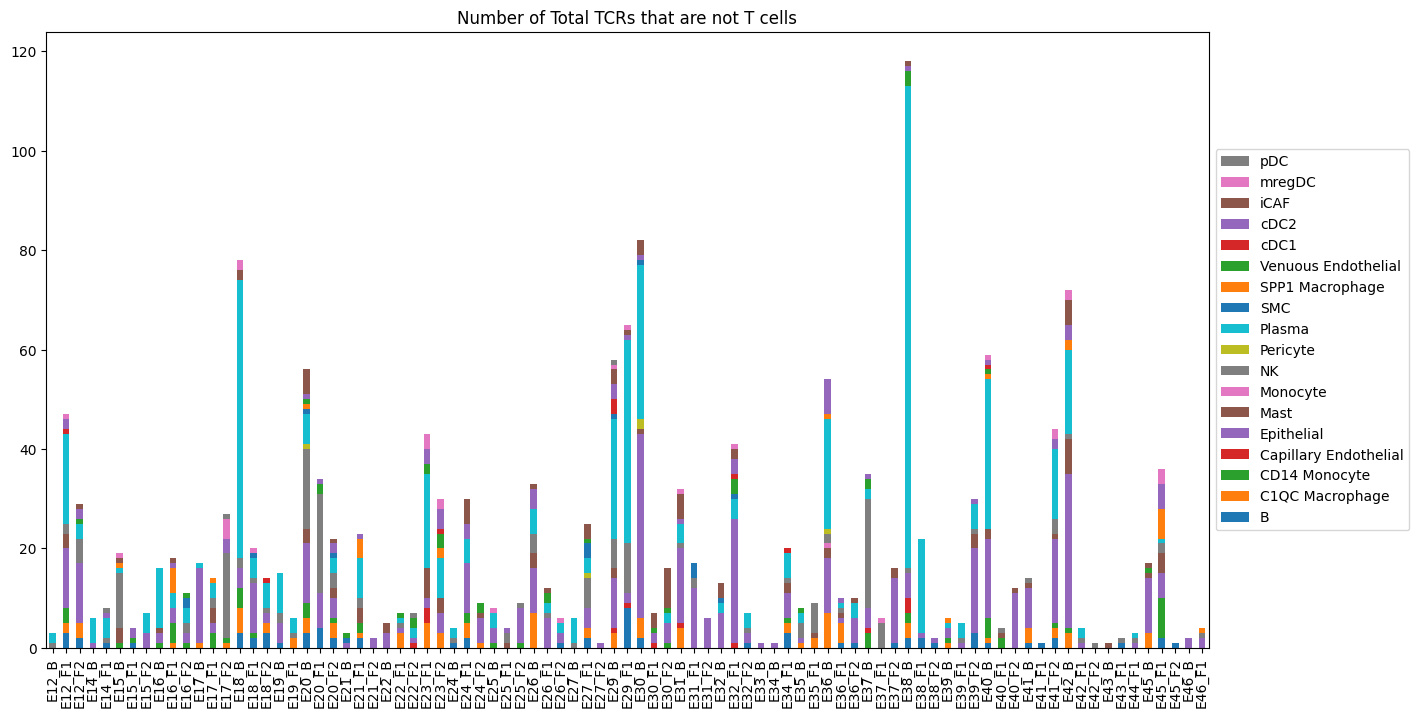

In [36]:
ax=pd.DataFrame(temp_dict).fillna(0).T.plot(kind='bar',stacked=True,figsize=(15,8))
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title('Number of Total TCRs that are not T cells')

In [37]:
pd.DataFrame(temp_dict).fillna(0).sum(axis=0)

E12_B      3.0
E12_F1    47.0
E12_F2    29.0
E14_B      6.0
E14_F1     8.0
          ... 
E45_B     17.0
E45_F1    36.0
E45_F2     1.0
E46_B      2.0
E46_F1     4.0
Length: 87, dtype: float64

Text(0.5, 1.0, 'Proportion of Total TCRs that are not T cells')

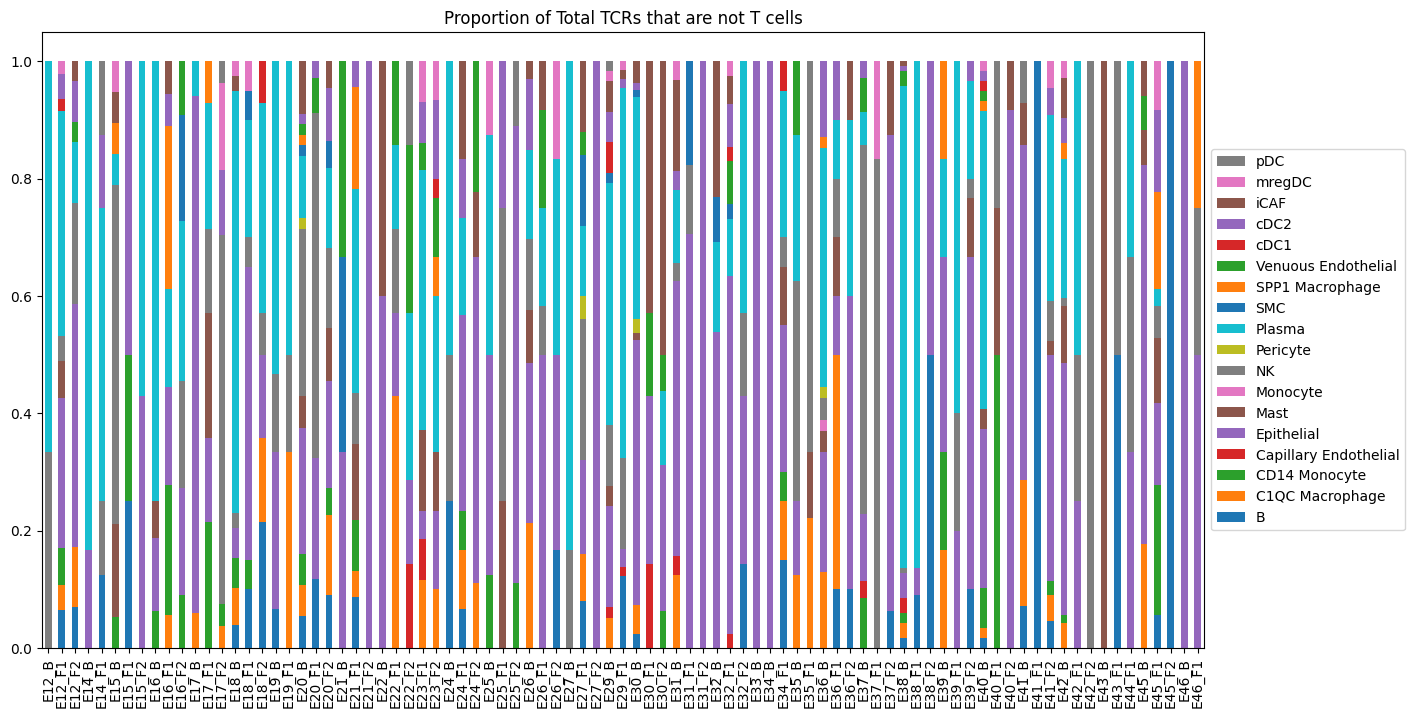

In [38]:
ax=pd.DataFrame(temp_dict).fillna(0).T.div(pd.DataFrame(temp_dict).fillna(0).sum(axis=0),axis=0).plot(kind='bar',stacked=True,figsize=(15,8))
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title('Proportion of Total TCRs that are not T cells')

In [39]:
adata_filt = adata[~adata.obs['annot_final'].isin(non_t)]

In [40]:
adata_filt[adata_filt.obs['sample_x'].isin(['E18_F1','E19_F1','E23_F2','E29_F1'])].obs['annot_final']

sample_index
E23_F2_AAACCTGGTATGAATG                               NaN
E23_F2_AAACCTGGTGGCCCTA    GZMK+ CD8 T progenitor ex Cell
E23_F2_AAACCTGGTTCAGTAC                               NaN
E23_F2_AAACCTGTCAAGGCTT         T naive/early memory Cell
E23_F2_AAACGGGTCGGTGTTA                       Tactiv Cell
                                        ...              
E29_F1_TTTGGTTAGATAGTCA    GZMK+ CD8 T progenitor ex Cell
E29_F1_TTTGGTTAGGTAAACT                               NaN
E29_F1_TTTGTCACACGAAACG         T naive/early memory Cell
E29_F1_TTTGTCATCGAATCCA                              Treg
E29_F1_TTTGTCATCTGGGCCA    GZMK+ CD8 T progenitor ex Cell
Name: annot_final, Length: 4634, dtype: category
Categories (14, object): ['CD8 Cytotoxic T Cell', 'CD8 HSP T cell', 'CD8 Tem Cell', 'GZMK+ CD8 T progenitor ex Cell', ..., 'Th17/Tc17', 'Tprolif Cell', 'Treg', 'gd T Cell']

In [41]:
tcr_annot_only_t_by_sample = adata_filt[~adata_filt.obs['annot_final'].isnull()].obs['sample_x'].value_counts()

In [42]:
qc_step_counts = pd.DataFrame({'T cell total' : t_cell_total_by_sample,
           'TCR total' : pd.Series(tcr_total_by_sample),
           'TCR non-null aa' : pd.Series(tcr_aa_by_sample),
           'TCR annot' : tcr_annot_by_sample,
           'TCR annot only T cell' : tcr_annot_only_t_by_sample})

In [43]:
t_tcr_diff = qc_step_counts['T cell total'] - qc_step_counts['TCR total']
tcr_tcr_aa_diff = qc_step_counts['TCR total'] - qc_step_counts['TCR non-null aa']
tcr_aa_tcr_annot_diff = qc_step_counts['TCR non-null aa'] - qc_step_counts['TCR annot']
tcr_annot_tcr_annot_t_diff = qc_step_counts['TCR annot'] - qc_step_counts['TCR annot only T cell']
tcr_annot_t = qc_step_counts['TCR annot only T cell']
qc_step_counts_diffs = pd.DataFrame({
    'TCR annot only T cell' : tcr_annot_t,
    'TCR annot - TCR annot only T cell' : tcr_annot_tcr_annot_t_diff,
    'TCR non-null aa - TCR annot' : tcr_aa_tcr_annot_diff,
    'TCR total - TCR non-null aa' : tcr_tcr_aa_diff,
    #'T cell total - TCR total' : t_tcr_diff
})

In [44]:
qc_step_counts_diffs = qc_step_counts_diffs.sort_index()

In [45]:
qc_step_counts_diffs

,TCR annot only T cell,TCR annot - TCR annot only T cell,TCR non-null aa - TCR annot,TCR total - TCR non-null aa
E12_B,231,3,4,48
E12_F1,1452,47,360,613
E12_F2,1576,29,75,462
E14_B,261,6,3,30
E14_F1,242,8,14,43
...,...,...,...,...
E45_F1,527,36,26,121
E45_F2,71,1,1,8
E46_B,144,2,5,14
E46_F1,482,4,26,91


Text(0.5, 1.0, 'Number of Total TCRs by Sample falling into each QC category')

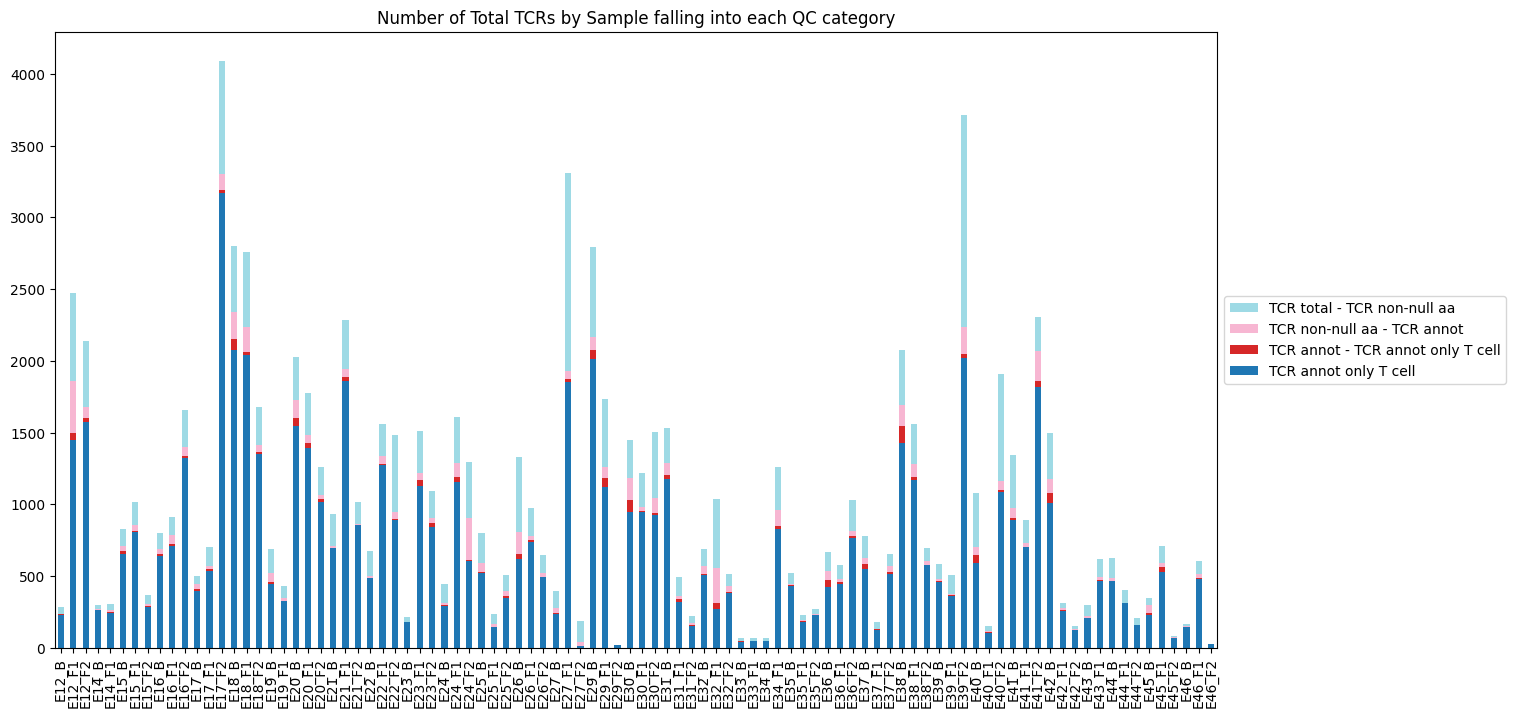

In [46]:
ax=qc_step_counts_diffs.plot(kind='bar',stacked=True,colormap='tab20',figsize=(15,8))
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title('Number of Total TCRs by Sample falling into each QC category')

Text(0.5, 1.0, 'Proportion of Total TCRs by Sample falling into each QC category')

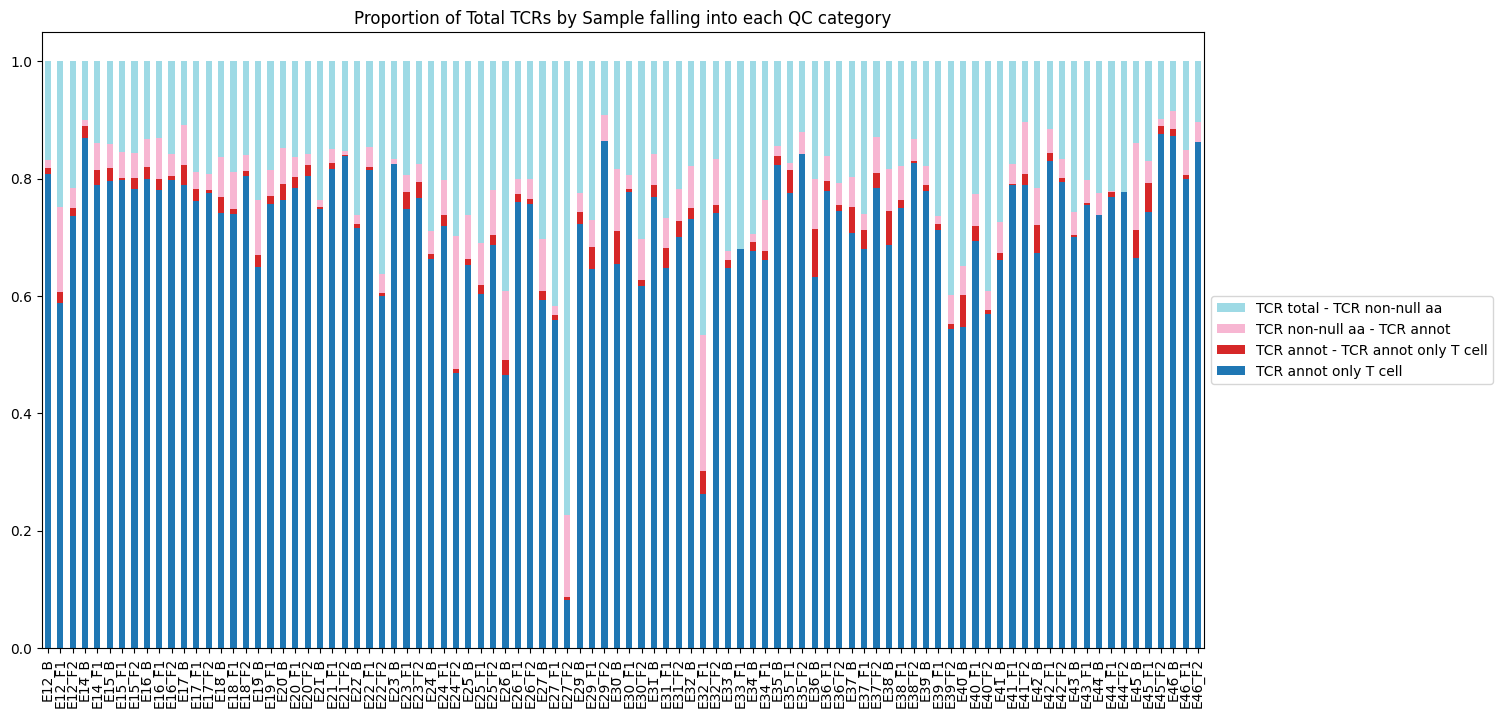

In [47]:
ax=qc_step_counts_diffs.div(qc_step_counts_diffs.sum(axis=1),axis=0).plot(kind='bar',stacked=True,colormap='tab20',figsize=(15,8))
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title('Proportion of Total TCRs by Sample falling into each QC category')

In [48]:
ax.get_facecolor()

(1.0, 1.0, 1.0, 1.0)

In [49]:
t_tcr_diff = qc_step_counts['T cell total'] - qc_step_counts['TCR annot only T cell']
tcr_annot_t = qc_step_counts['TCR annot only T cell']
qc_step_counts_diffs = pd.DataFrame({
    'TCR annot only T cell' : tcr_annot_t,
    'T cell total - TCR annot only T cell' : t_tcr_diff
})

In [50]:
qc_step_counts_diffs = qc_step_counts_diffs.sort_index()
color_dict = {
    'T cell total - TCR annot only T cell' : '#c7c7c7',
    'TCR annot only T cell' : '#1f77b4'
}

Text(0.5, 1.0, 'Number of Total T cells that have a matched TCR by sample')

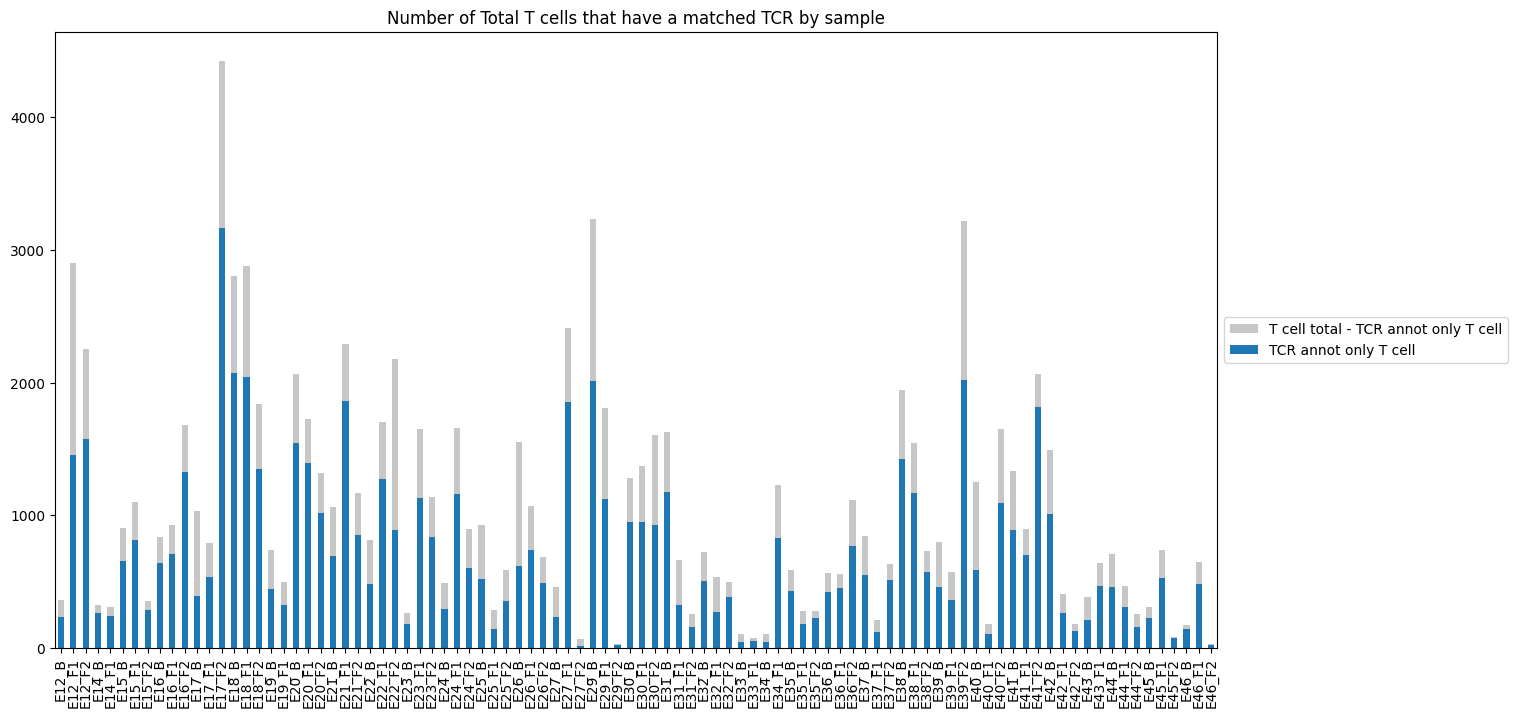

In [51]:
ax=qc_step_counts_diffs.plot(kind='bar',stacked=True,colormap='tab20',figsize=(15,8),color=color_dict)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title('Number of Total T cells that have a matched TCR by sample')

Text(0.5, 1.0, 'Proportion of Total T cells that have a matched TCR by sample')

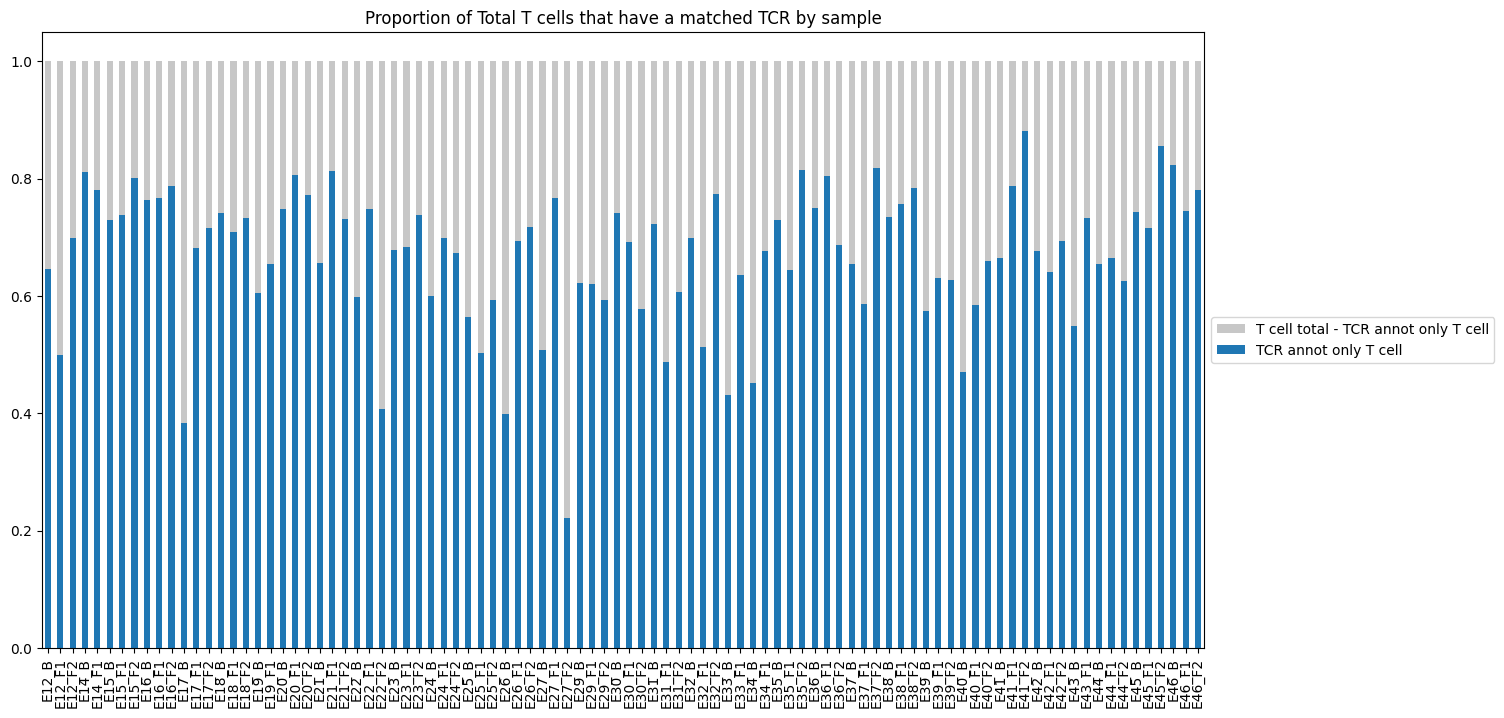

In [52]:
ax=qc_step_counts_diffs.div(qc_step_counts_diffs.sum(axis=1),axis=0).plot(kind='bar',stacked=True,colormap='tab20',figsize=(15,8),color=color_dict)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title('Proportion of Total T cells that have a matched TCR by sample')

In [53]:
t_tcr_diff = qc_step_counts['T cell total'] - qc_step_counts['TCR total']
tcr_total = qc_step_counts['TCR total']
qc_step_counts_diffs = pd.DataFrame({
    'TCR total' : tcr_total,
    'T cell total - TCR total' : t_tcr_diff
})

In [54]:
qc_step_counts_diffs = qc_step_counts_diffs.sort_values(by='TCR total',ascending=False)
color_dict = {
    'T cell total - TCR total' : '#c7c7c7',
    'TCR total' : '#9edae5'
}

Text(0.5, 1.0, 'Number of Total TCRs by Sample falling into each QC category')

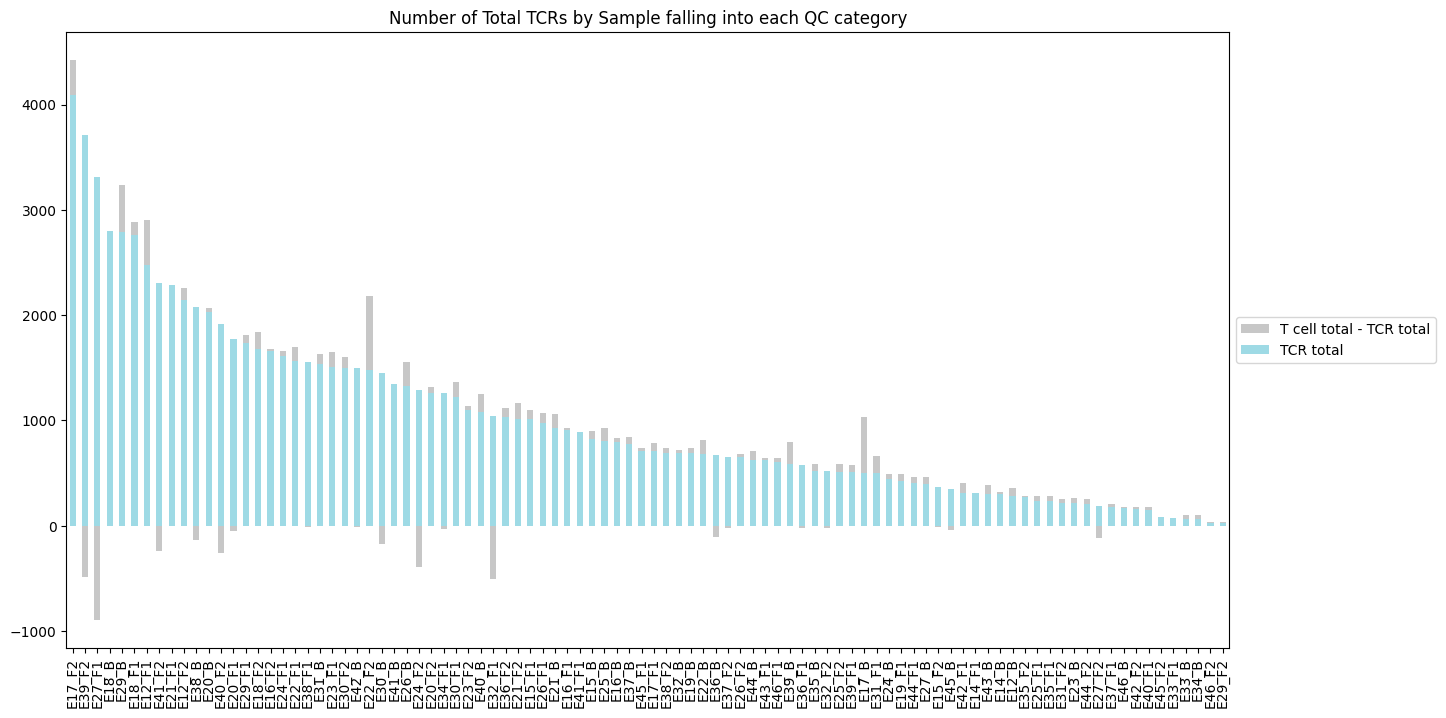

In [55]:
ax=qc_step_counts_diffs.plot(kind='bar',stacked=True,colormap='tab20',figsize=(15,8),color=color_dict)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title('Number of Total TCRs by Sample falling into each QC category')

# Save file

In [56]:
import os
!gsutil -m cp gs://vm_backups_arnav/ge_korea/raw_data/count_matricies/am_reprocessed_matrix_20221230.h5ad {'/home/jupyter/data/ge_korea/raw_data/count_matricies/am_reprocessed_matrix_20221230.h5ad'}
adata_am = sc.read_h5ad('/home/jupyter/data/ge_korea/raw_data/count_matricies/am_reprocessed_matrix_20221230.h5ad')
os.remove('/home/jupyter/data/ge_korea/raw_data/count_matricies/am_reprocessed_matrix_20221230.h5ad')

Copying gs://vm_backups_arnav/ge_korea/raw_data/count_matricies/am_reprocessed_matrix_20221230.h5ad...
- [1/1 files][  8.5 GiB/  8.5 GiB] 100% Done  74.2 MiB/s ETA 00:00:00           
Operation completed over 1 objects/8.5 GiB.                                      


In [57]:
adata_am

AnnData object with n_obs × n_vars = 357312 × 36588
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Location', 'TimePoint', 'HER2', 'Patient', 'BoR', 'Response', 'TCGA', 'Response_TimePoint', 'RNA_snn_res.0.1', 'seurat_clusters', 'annot_1st', 'annot_2nd', 'annot_temp', 'annot_3rd', 'Time', 'Local', 'annot_4th', 'ident', 'PFS', 'OS', 'Progression status', 'n_genes_by_counts', 'total_counts', 'doublet'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Progression status_colors', 'X_name', 'annot_2nd_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'HARMONY', 'PCA', 'UMAP', 'X_pca', 'X_pca_harmony', 'X_pca_harmony_original', 'X_umap', 'X_umap_original'
    varm: 'PCs'
    layers: 'raw_counts'
    obsp: 'connectivities', 'distances'

In [58]:
patient_table = adata_am.obs[['Patient','Progression status','Response']].drop_duplicates()
patient_table.index = patient_table['Patient']
del patient_table['Patient']

In [59]:
patient_table['Progression status'].value_counts()

Slow    24
Fast     9
Name: Progression status, dtype: int64

In [60]:
adata.obs['response'] = adata.obs['patient'].map(patient_table['Response'].to_dict())

In [61]:
adata.obs['progression'] = adata.obs['patient'].map(patient_table['Progression status'].to_dict())

In [62]:
adata.obs['progression']

sample_index
E30_F1_AAACCTGAGTGGACGT    Fast
E30_F1_AAACCTGTCTCGGACG    Fast
E30_F1_AAACGGGCAACCGCCA    Fast
E30_F1_AAACGGGCACTTCGAA    Fast
E30_F1_AAAGATGCAAGTTAAG    Fast
                           ... 
E29_F1_TTTGGTTAGATAGTCA    Slow
E29_F1_TTTGGTTAGGTAAACT    Slow
E29_F1_TTTGTCACACGAAACG    Slow
E29_F1_TTTGTCATCGAATCCA    Slow
E29_F1_TTTGTCATCTGGGCCA    Slow
Name: progression, Length: 73652, dtype: object

In [124]:
adata = adata[~(adata.obs['annot_final'].isin(non_t)) & ~(adata.obs['annot_final'].isnull())]

In [125]:
adata

View of AnnData object with n_obs × n_vars = 66813 × 36601
    obs: 'sample_x', 'patient', 'timepoint', 'normal', 'batch', 'is_cell', 'high_confidence', 'multi_chain', 'extra_chains', 'IR_VJ_1_c_call', 'IR_VJ_2_c_call', 'IR_VDJ_1_c_call', 'IR_VDJ_2_c_call', 'IR_VJ_1_consensus_count', 'IR_VJ_2_consensus_count', 'IR_VDJ_1_consensus_count', 'IR_VDJ_2_consensus_count', 'IR_VJ_1_d_call', 'IR_VJ_2_d_call', 'IR_VDJ_1_d_call', 'IR_VDJ_2_d_call', 'IR_VJ_1_duplicate_count', 'IR_VJ_2_duplicate_count', 'IR_VDJ_1_duplicate_count', 'IR_VDJ_2_duplicate_count', 'IR_VJ_1_j_call', 'IR_VJ_2_j_call', 'IR_VDJ_1_j_call', 'IR_VDJ_2_j_call', 'IR_VJ_1_junction', 'IR_VJ_2_junction', 'IR_VDJ_1_junction', 'IR_VDJ_2_junction', 'IR_VJ_1_junction_aa', 'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa', 'IR_VJ_1_locus', 'IR_VJ_2_locus', 'IR_VDJ_1_locus', 'IR_VDJ_2_locus', 'IR_VJ_1_productive', 'IR_VJ_2_productive', 'IR_VDJ_1_productive', 'IR_VDJ_2_productive', 'IR_VJ_1_v_call', 'IR_VJ_2_v_call', 'I

In [126]:
adata.write('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new.h5ad')

# Training

In [17]:
import comet_ml
import scanpy as sc

import os
import sys

In [18]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata.h5ad')

In [19]:
import tcr_embedding.utils_training as utils
from tcr_embedding.utils_preprocessing import group_shuffle_split
utils.fix_seeds(42)

train, val = group_shuffle_split(adata, group_col='clonotype', val_split=0.20, random_seed=42)
adata.obs['set'] = 'train'
adata.obs.loc[val.obs.index, 'set'] = 'val'

In [20]:
adata.obs['patient']

sample_index
E30_F1_AAACCTGAGTGGACGT    E30
E30_F1_AAACCTGTCTCGGACG    E30
E30_F1_AAACGGGCAACCGCCA    E30
E30_F1_AAACGGGCACTTCGAA    E30
E30_F1_AAAGATGCAAGTTAAG    E30
                          ... 
E29_F1_TTTGGTTAGATAGTCA    E29
E29_F1_TTTGGTTAGGTAAACT    E29
E29_F1_TTTGTCACACGAAACG    E29
E29_F1_TTTGTCATCGAATCCA    E29
E29_F1_TTTGTCATCTGGGCCA    E29
Name: patient, Length: 73652, dtype: category
Categories (33, object): ['E12', 'E14', 'E15', 'E16', ..., 'E43', 'E44', 'E45', 'E46']

In [21]:
params_experiment = {
    'study_name': f'ge_korea',
    'comet_workspace': None, 
    'model_name': 'tcr',
    'balanced_sampling': 'clonotype',
    'metadata': [],
    'save_path': '/home/jupyter/data/ge_korea/results/tcr_analysis/saved_models_tcr',
    'conditional': 'patient',
    'n_epochs': 200,
}

In [22]:
params_optimization = {
    'name': 'pseudo_metric',
    'prediction_labels':
        {'clonotype': 2,
         'timepoint': 2}
}

In [23]:
from tcr_embedding.models.model_selection import run_model_selection

timeout = (30*60)
n_samples = 3
n_gpus = 1
run_model_selection(adata, params_experiment, params_optimization, n_samples, timeout, n_gpus)

[I 2024-07-24 18:06:56,306] A new study created in RDB with name: ge_korea
[W 2024-07-24 18:06:57,777] Trial 0 failed because of the following error: KeyError('patient')
Traceback (most recent call last):
  File "/home/jupyter/mambaforge/envs/mvTCR/lib/python3.8/site-packages/optuna/study/_optimize.py", line 213, in _run_trial
    value_or_values = func(trial)
  File "/home/jupyter/mambaforge/envs/mvTCR/lib/python3.8/site-packages/tcr_embedding/models/model_selection.py", line 140, in <lambda>
    study.optimize(lambda trial: objective(trial, adata, suggest_params, params_experiment, params_optimization),
  File "/home/jupyter/mambaforge/envs/mvTCR/lib/python3.8/site-packages/tcr_embedding/models/model_selection.py", line 98, in objective
    model = model(adata, params_architecture, params_experiment['balanced_sampling'], params_experiment['metadata'],
  File "/home/jupyter/mambaforge/envs/mvTCR/lib/python3.8/site-packages/tcr_embedding/models/mixture_modules/separate_model.py", line 

KeyError: 'patient'

In [24]:
adata_annot = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_final_annot.h5ad')

In [25]:
adata_annot.obs['stripped_index'] = [item.split('-')[0] for item in adata_annot.obs.index.tolist()]
adata_annot.obs['sample_index'] = adata_annot.obs[['sample', 'stripped_index']].agg('_'.join, axis=1)

In [26]:
del adata_annot.obs['stripped_index']
adata_annot.obs = adata_annot.obs.set_index('sample_index')

In [27]:
adata_annot.obs['annot_final']

sample_index
E30_F1_AAACCTGTCAAGATCC              Plasma
E30_F1_AAGGTTCAGAGGACGG              Plasma
E30_F1_ACGCAGCCAATCGAAA              Plasma
E30_F1_ACGGGTCCAGCCAGAA              Plasma
E30_F1_ACTTGTTTCGAGAACG              Plasma
                                  ...      
E43_B_DN_TTTGCGCGTTGAGTTC    CD8 HSP T cell
E43_B_DN_TTTGTCAAGTGCGTGA      CD8 Tem Cell
E43_B_DN_TTTGTCACAAGCGAGT         gd T Cell
E43_B_DN_TTTGTCACAGCGTTCG      CD8 Tem Cell
E43_B_DN_TTTGTCAGTACCCAAT      CD8 Tem Cell
Name: annot_final, Length: 392977, dtype: category
Categories (37, object): ['B', 'C1QC Macrophage', 'CD4 T naive/early memory Cell', 'CD8 Cytotoxic T Cell', ..., 'gd T Cell', 'iCAF', 'mregDC', 'pDC']

In [27]:
adata.obs['annot_final'] = adata_annot.obs['annot_final']

In [28]:
np.sum(adata.obs['annot_final'].value_counts())

68525

In [29]:
adata

AnnData object with n_obs × n_vars = 73652 × 36601
    obs: 'sample_x', 'patient', 'timepoint', 'normal', 'batch', 'is_cell', 'high_confidence', 'multi_chain', 'extra_chains', 'IR_VJ_1_c_call', 'IR_VJ_2_c_call', 'IR_VDJ_1_c_call', 'IR_VDJ_2_c_call', 'IR_VJ_1_consensus_count', 'IR_VJ_2_consensus_count', 'IR_VDJ_1_consensus_count', 'IR_VDJ_2_consensus_count', 'IR_VJ_1_d_call', 'IR_VJ_2_d_call', 'IR_VDJ_1_d_call', 'IR_VDJ_2_d_call', 'IR_VJ_1_duplicate_count', 'IR_VJ_2_duplicate_count', 'IR_VDJ_1_duplicate_count', 'IR_VDJ_2_duplicate_count', 'IR_VJ_1_j_call', 'IR_VJ_2_j_call', 'IR_VDJ_1_j_call', 'IR_VDJ_2_j_call', 'IR_VJ_1_junction', 'IR_VJ_2_junction', 'IR_VDJ_1_junction', 'IR_VDJ_2_junction', 'IR_VJ_1_junction_aa', 'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa', 'IR_VJ_1_locus', 'IR_VJ_2_locus', 'IR_VDJ_1_locus', 'IR_VDJ_2_locus', 'IR_VJ_1_productive', 'IR_VJ_2_productive', 'IR_VDJ_1_productive', 'IR_VDJ_2_productive', 'IR_VJ_1_v_call', 'IR_VJ_2_v_call', 'IR_VDJ_1_

In [61]:
params_experiment = {
    'study_name': f'ge_korea',
    'comet_workspace': None, 
    'model_name': 'tcr',
    'balanced_sampling': 'clonotype',
    'metadata': [],
    'save_path': '/home/jupyter/data/ge_korea/results/tcr_analysis/saved_models_tcr',
    'conditional': 'sample_x',
    'n_epochs': 200,
}

In [42]:
adata.obs['timepoint'].isnull().value_counts()

False    73652
Name: timepoint, dtype: int64

In [44]:
adata.obs['annot_final'].isnull().value_counts()

False    68525
True      5127
Name: annot_final, dtype: int64

In [45]:
adata.obs.dropna(subset=['annot_final'], inplace=True)

In [59]:
adata = adata[adata.obs_names,:]

In [62]:
params_optimization = {
    'name': 'pseudo_metric',
    'prediction_labels':
        {'clonotype': 2,
         'annot_final': 2}
}

In [63]:
from tcr_embedding.models.model_selection import run_model_selection

timeout = (30*60)
n_samples = 3
n_gpus = 1
run_model_selection(adata, params_experiment, params_optimization, n_samples, timeout, n_gpus)

[I 2024-01-25 18:27:15,280] A new study created in RDB with name: ge_korea
100%|██████████| 200/200 [3:29:16<00:00, 62.78s/it]  
[I 2024-01-25 21:56:35,523] Trial 0 finished with value: 0.43079138681354145 and parameters: {'dropout': 0.1, 'activation': 'linear', 'hdim': 500, 'shared_hidden': 100, 'tfmr_encoding_layers': 1, 'loss_weights_kl': 2.2310108018679187e-10, 'lr': 0.0005399484409787432, 'zdim': 35, 'tfmr_embedding_size': 64, 'tfmr_num_heads': 2, 'tfmr_dropout': 0.05}. Best is trial 0 with value: 0.43079138681354145.


Study statistics:
  Number of finished trials: 1
  Number of pruned trials: 0
  Number of complete trials: 1
Best trial: 
  trial_0
  Value: 0.43079138681354145


In [65]:
path_model = '/home/jupyter/data/ge_korea/results/tcr_analysis/saved_models_tcr/trial_0/best_model_by_metric.pt'
model = utils.load_model(adata, path_model)

In [66]:
latent_moe = model.get_latent(adata, metadata=[], return_mean=True)
latent_moe.obs = adata.obs.copy()

In [68]:
latent_moe

AnnData object with n_obs × n_vars = 68525 × 35
    obs: 'sample_x', 'patient', 'timepoint', 'normal', 'batch', 'is_cell', 'high_confidence', 'multi_chain', 'extra_chains', 'IR_VJ_1_c_call', 'IR_VJ_2_c_call', 'IR_VDJ_1_c_call', 'IR_VDJ_2_c_call', 'IR_VJ_1_consensus_count', 'IR_VJ_2_consensus_count', 'IR_VDJ_1_consensus_count', 'IR_VDJ_2_consensus_count', 'IR_VJ_1_d_call', 'IR_VJ_2_d_call', 'IR_VDJ_1_d_call', 'IR_VDJ_2_d_call', 'IR_VJ_1_duplicate_count', 'IR_VJ_2_duplicate_count', 'IR_VDJ_1_duplicate_count', 'IR_VDJ_2_duplicate_count', 'IR_VJ_1_j_call', 'IR_VJ_2_j_call', 'IR_VDJ_1_j_call', 'IR_VDJ_2_j_call', 'IR_VJ_1_junction', 'IR_VJ_2_junction', 'IR_VDJ_1_junction', 'IR_VDJ_2_junction', 'IR_VJ_1_junction_aa', 'IR_VJ_2_junction_aa', 'IR_VDJ_1_junction_aa', 'IR_VDJ_2_junction_aa', 'IR_VJ_1_locus', 'IR_VJ_2_locus', 'IR_VDJ_1_locus', 'IR_VDJ_2_locus', 'IR_VJ_1_productive', 'IR_VJ_2_productive', 'IR_VDJ_1_productive', 'IR_VDJ_2_productive', 'IR_VJ_1_v_call', 'IR_VJ_2_v_call', 'IR_VDJ_1_v_c

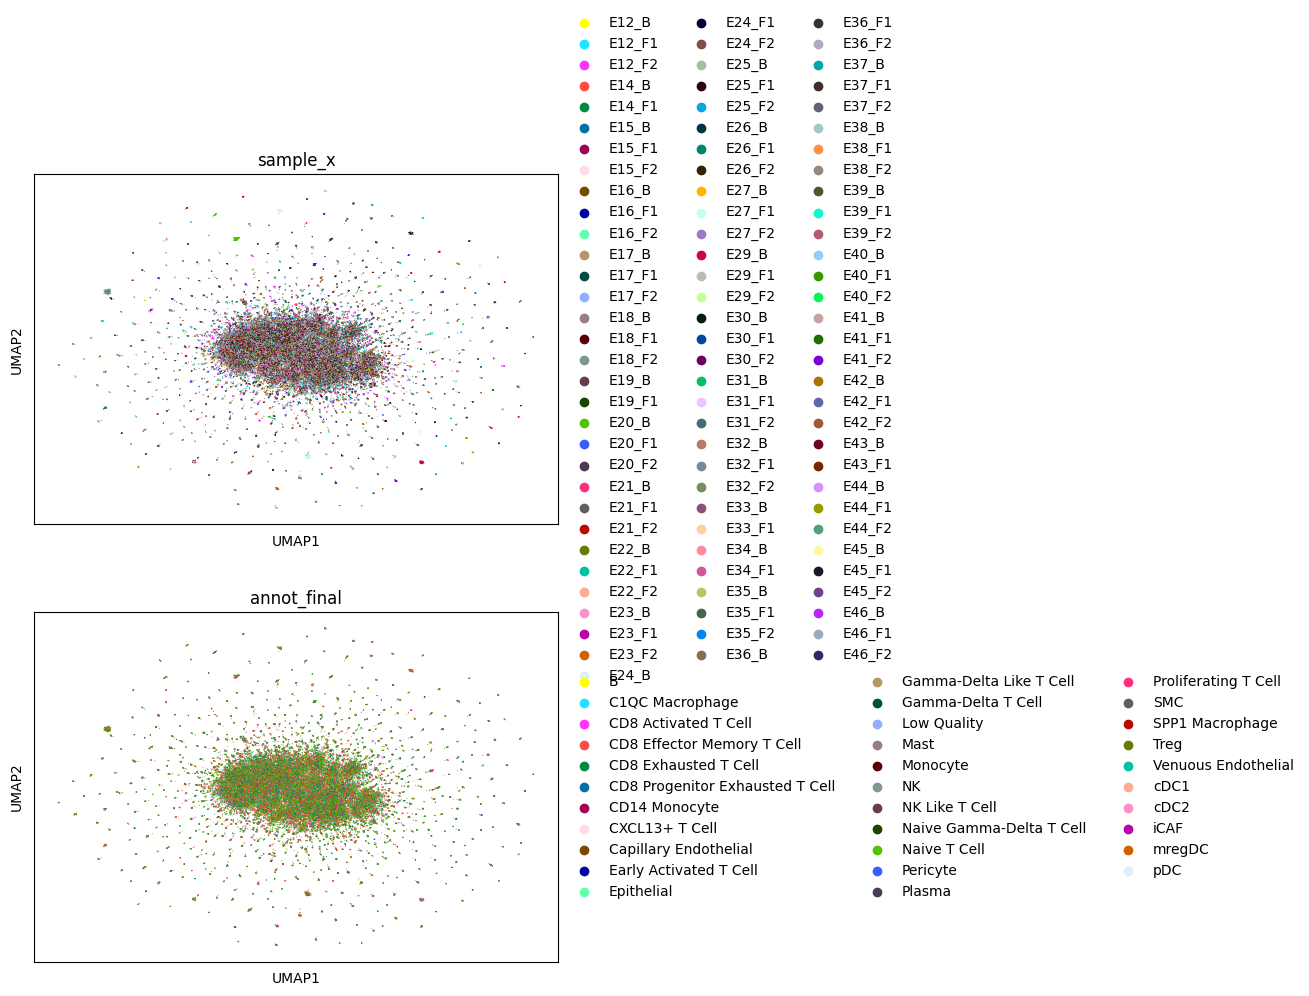

In [69]:
sc.pp.neighbors(latent_moe, use_rep='X')
sc.tl.umap(latent_moe)
sc.pl.umap(latent_moe, color=['sample_x', 'annot_final'],ncols=1)

In [ ]:
sc.pl.umap(latent_moe, color=['clonotype'],ncols=1)

In [ ]:
adata